<a href="https://colab.research.google.com/github/davedawitdave/contrast-learning-and-mobile-vit/blob/main_rep/temprature_and_augmentation_experment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Controlled Experiments & Failure Analysis

In this final notebook we run controlled experiments to understand **why** representations succeed or fail.

We focus on two key factors requested:
1. **Weak vs Strong augmentation** — we train EfficientNet-B0 using only weak augmentations.
2. **Temperature (τ) sensitivity** — we compare τ = 0.5 (default) vs τ = 0.1 (sharper focus on hard negatives).

Both experiments use **only EfficientNet-B0**, **10 epochs**, and **weak augmentation only**.  
Models are saved to a new dedicated folder: `/content/drive/MyDrive/contrastive_models/experiments/`

We then compare these two new models against the original strong-augmentation EfficientNet-B0 from Notebook 1 using:
- Geometry metrics (Alignment, Uniformity, Silhouette, Davies-Bouldin, Intra/Inter)
- k-NN accuracy + per-model confusion matrices
- t-SNE & PCA visualizations
- Cosine similarity distributions

This gives us deep mechanistic insight into the importance of strong augmentations and temperature.

In [1]:
from google.colab import drive
import os

drive.mount('/content/drive')
os.makedirs('/content/drive/MyDrive/contrastive_models/experiments', exist_ok=True)
print(" Google Drive mounted and experiments folder created")

Mounted at /content/drive
 Google Drive mounted and experiments folder created


In [2]:
#  Imports (updated with Dataset)
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset   # ← Dataset added here
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, silhouette_score, davies_bouldin_score
import seaborn as sns
import tqdm
from torchvision.datasets import CIFAR10
import torchvision.transforms as transforms
import torchvision.models as models
import pandas as pd
%matplotlib inline

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [3]:
class EfficientNetEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.effnet = models.efficientnet_b0(weights='IMAGENET1K_V1')
        self.effnet.classifier = nn.Identity()
    def forward(self, x):
        x = F.interpolate(x, size=(224, 224), mode='bilinear', align_corners=False)
        return self.effnet(x)

class ProjectionHead(nn.Module):
    def __init__(self, input_dim, output_dim=128, hidden_dim=512, use_head=True):
        super().__init__()
        self.use_head = use_head
        if use_head:
            self.mlp = nn.Sequential(
                nn.Linear(input_dim, hidden_dim),
                nn.ReLU(inplace=True),
                nn.Linear(hidden_dim, output_dim)
            )
        else:
            self.mlp = nn.Identity()
    def forward(self, x):
        return self.mlp(x)

print(" EfficientNetEncoder and ProjectionHead defined")

 EfficientNetEncoder and ProjectionHead defined


In [4]:
weak_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

print(" Weak augmentation pipeline defined (only RandomHorizontalFlip + normalization)")

 Weak augmentation pipeline defined (only RandomHorizontalFlip + normalization)


In [5]:
class ContrastiveDataset(Dataset):
    def __init__(self, base_dataset, transform1, transform2):
        self.base_dataset = base_dataset
        self.transform1 = transform1
        self.transform2 = transform2

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        img, label = self.base_dataset[idx]
        x1 = self.transform1(img)
        x2 = self.transform2(img)
        return x1, x2, label

print(" ContrastiveDataset ready")

 ContrastiveDataset ready


In [6]:
class InfoNCELoss(nn.Module):
    def __init__(self, temperature=0.5):
        super().__init__()
        self.temperature = temperature
    def forward(self, z1, z2):
        batch_size = z1.shape[0]
        z = torch.cat([z1, z2], dim=0)
        z = F.normalize(z, dim=1)
        sim_matrix = torch.matmul(z, z.T) / self.temperature
        mask = torch.eye(2 * batch_size, device=z.device).bool()
        sim_matrix = sim_matrix.masked_fill(mask, float('-inf'))
        targets = torch.cat([torch.arange(batch_size, device=z.device) + batch_size,
                             torch.arange(batch_size, device=z.device)], dim=0)
        loss = F.cross_entropy(sim_matrix, targets)
        return loss

def train_experiment(tau=0.5, epochs=10, exp_name="EfficientNetB0_weak_tau0.5"):
    print(f"\n Running experiment: {exp_name} | τ = {tau} | Weak aug only | {epochs} epochs")

    contrastive_ds = ContrastiveDataset(train_dataset, weak_transform, weak_transform)
    loader = DataLoader(contrastive_ds, batch_size=128, shuffle=True,
                        num_workers=4, pin_memory=True, drop_last=True)

    encoder = EfficientNetEncoder().to(device)
    proj = ProjectionHead(input_dim=1280, output_dim=128).to(device)

    criterion = InfoNCELoss(temperature=tau).to(device)
    optimizer = torch.optim.AdamW(list(encoder.parameters()) + list(proj.parameters()),
                                  lr=1e-3, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    scaler = torch.cuda.amp.GradScaler()

    for epoch in range(epochs):
        encoder.train()
        proj.train()
        total_loss = 0.0
        pbar = tqdm.tqdm(loader, desc=f"Epoch {epoch+1}/{epochs}")
        for x1, x2, _ in pbar:
            x1, x2 = x1.to(device), x2.to(device)
            optimizer.zero_grad()
            with torch.cuda.amp.autocast():
                z1 = proj(encoder(x1))
                z2 = proj(encoder(x2))
                loss = criterion(z1, z2)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            total_loss += loss.item()
            pbar.set_postfix({"loss": f"{loss.item():.4f}"})
        scheduler.step()
        print(f"   Epoch {epoch+1:2d} | Loss: {total_loss/len(loader):.4f}")

    save_path = f'/content/drive/MyDrive/contrastive_models/experiments/{exp_name}.pth'
    torch.save({
        'encoder_state': encoder.state_dict(),
        'proj_state': proj.state_dict(),
        'tau': tau,
        'epochs': epochs,
        'aug': 'weak'
    }, save_path)
    print(f" Model saved: {save_path}")
    return encoder, proj

In [7]:
train_dataset = CIFAR10(root='./data', train=True, download=True, transform=None)
print(f"Train dataset loaded: {len(train_dataset)} images")

100%|██████████| 170M/170M [00:22<00:00, 7.51MB/s]


Train dataset loaded: 50000 images


In [8]:
eff_weak_tau05, proj_tau05 = train_experiment(tau=0.5, epochs=10,
                                              exp_name="EfficientNetB0_weak_tau0.5")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()



 Running experiment: EfficientNetB0_weak_tau0.5 | τ = 0.5 | Weak aug only | 10 epochs
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 140MB/s]
/tmp/ipykernel_8114/1209178230.py:31: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
Epoch 1/10:   0%|          | 0/390 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/tmp/ipykernel_8114/1209178230.py:41: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Epoch 1/10: 100%|██

   Epoch  1 | Loss: 3.6382


Epoch 2/10: 100%|██████████| 390/390 [04:08<00:00,  1.57it/s, loss=3.5899]


...

   Epoch  8 | Loss: 3.5740


Epoch 9/10: 100%|██████████| 390/390 [04:08<00:00,  1.57it/s, loss=3.5740]


   Epoch  9 | Loss: 3.5728


Epoch 10/10: 100%|██████████| 390/390 [04:08<00:00,  1.57it/s, loss=3.5710]


   Epoch 10 | Loss: 3.5719
 Model saved: /content/drive/MyDrive/contrastive_models/experiments/EfficientNetB0_weak_tau0.5.pth


In [9]:
eff_weak_tau01, proj_tau01 = train_experiment(tau=0.1, epochs=10,
                                              exp_name="EfficientNetB0_weak_tau0.1")


 Running experiment: EfficientNetB0_weak_tau0.1 | τ = 0.1 | Weak aug only | 10 epochs


/tmp/ipykernel_8114/1209178230.py:31: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
Epoch 1/10:   0%|          | 0/390 [00:00<?, ?it/s]/tmp/ipykernel_8114/1209178230.py:41: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Epoch 1/10: 100%|██████████| 390/390 [04:08<00:00,  1.57it/s, loss=0.0257]


   Epoch  1 | Loss: 0.0738


Epoch 2/10: 100%|██████████| 390/390 [04:08<00:00,  1.57it/s, loss=0.0218]


   Epoch  2 | Loss: 0.0230


...

   Epoch  8 | Loss: 0.0178


Epoch 9/10: 100%|██████████| 390/390 [04:08<00:00,  1.57it/s, loss=0.0179]


   Epoch  9 | Loss: 0.0175


Epoch 10/10: 100%|██████████| 390/390 [04:07<00:00,  1.58it/s, loss=0.0175]

   Epoch 10 | Loss: 0.0173
 Model saved: /content/drive/MyDrive/contrastive_models/experiments/EfficientNetB0_weak_tau0.1.pth


In [13]:
# Extract Embeddings - ONLY the two weak-augmentation models (time-saving version)

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])
test_ds = CIFAR10(root='./data', train=False, transform=test_transform)

@torch.no_grad()
def extract_embeddings(encoder, proj, dataset, batch_size=128):
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False,
                        num_workers=2, pin_memory=True)
    embeddings = []
    labels = []
    encoder.eval()
    proj.eval()
    for x, y in tqdm.tqdm(loader, desc="Extracting embeddings"):
        x = x.to(device)
        emb = proj(encoder(x)).cpu()
        embeddings.append(emb)
        labels.extend(y.numpy())
    return torch.cat(embeddings, dim=0).numpy(), np.array(labels)

print(" Extracting embeddings for the TWO weak-augmentation models only...")

emb_tau05, lbls = extract_embeddings(eff_weak_tau05, proj_tau05, test_ds)
emb_tau01, _     = extract_embeddings(eff_weak_tau01, proj_tau01, test_ds)

print(" Embeddings extracted successfully for:")
print("   • Weak Aug + τ = 0.5 (10 epochs)")
print("   • Weak Aug + τ = 0.1 (10 epochs)")
print(f"   Total test embeddings: {len(lbls):,} per model")

 Extracting embeddings for the TWO weak-augmentation models only...


Extracting embeddings: 100%|██████████| 79/79 [00:11<00:00,  6.72it/s]

 Embeddings extracted successfully for:
   • Weak Aug + τ = 0.5 (10 epochs)
   • Weak Aug + τ = 0.1 (10 epochs)
   Total test embeddings: 10,000 per model


In [14]:
# two weak-augmentation models (different temperature)
model_dict = {
    "Weak Aug + τ = 0.5 (10 epochs)": (emb_tau05, lbls),
    "Weak Aug + τ = 0.1 (10 epochs)": (emb_tau01, lbls)
}

print(" Ready to compare only the two weak-augmentation models with different temperatures")

 Ready to compare only the two weak-augmentation models with different temperatures


 Computing k-NN Accuracy (k=20) and Confusion Matrices...


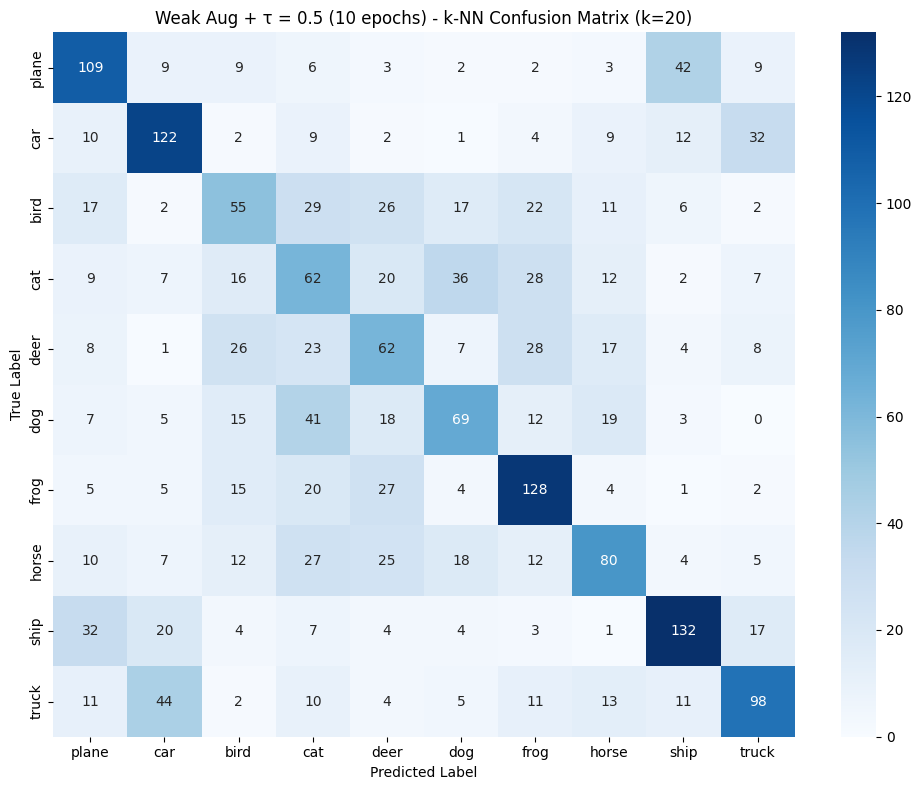

Weak Aug + τ = 0.5 (10 epochs)                | k-NN Accuracy: 45.85%


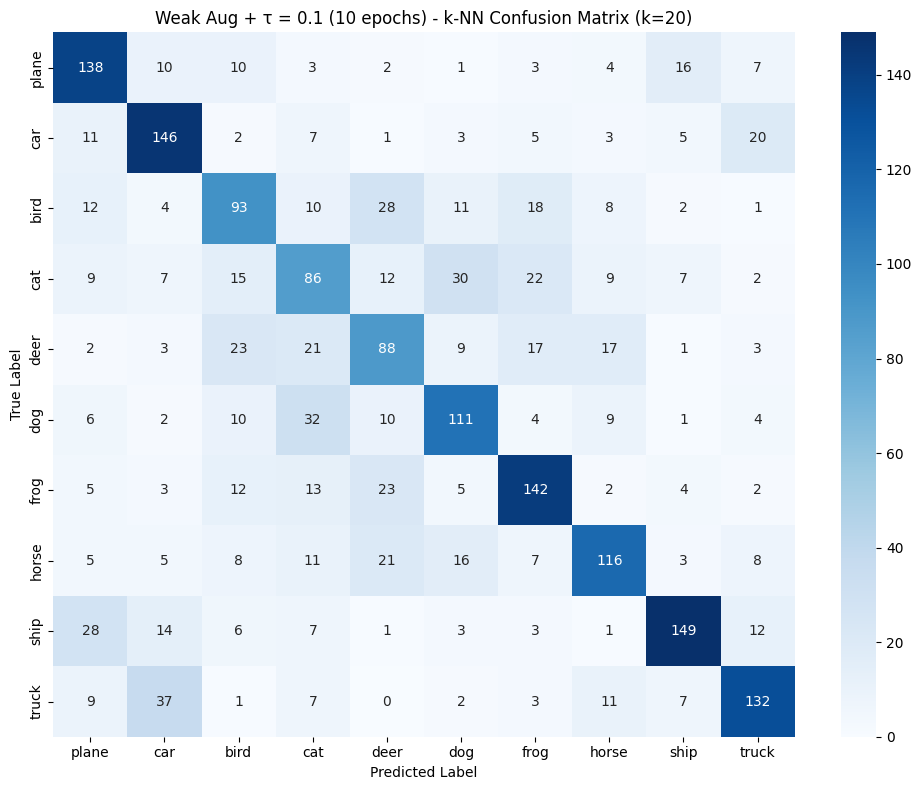

Weak Aug + τ = 0.1 (10 epochs)                | k-NN Accuracy: 60.05%


In [15]:
#  k-NN Accuracy and Confusion Matrices
print(" Computing k-NN Accuracy (k=20) and Confusion Matrices...")

knn_results = {}
classes = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

for name, (emb, lbls) in model_dict.items():
    n = len(emb)
    train_idx = int(0.8 * n)
    X_train, y_train = emb[:train_idx], lbls[:train_idx]
    X_test, y_test = emb[train_idx:], lbls[train_idx:]

    knn = KNeighborsClassifier(n_neighbors=20, metric='cosine')
    knn.fit(X_train, y_train)
    pred = knn.predict(X_test)

    acc = accuracy_score(y_test, pred)
    knn_results[name] = acc

    # Confusion Matrix
    cm = confusion_matrix(y_test, pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes)
    plt.title(f"{name} - k-NN Confusion Matrix (k=20)")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.show()

    print(f"{name:45s} | k-NN Accuracy: {acc*100:.2f}%")

 Generating PCA and t-SNE visualizations...

Weak Aug + τ = 0.5 (10 epochs)


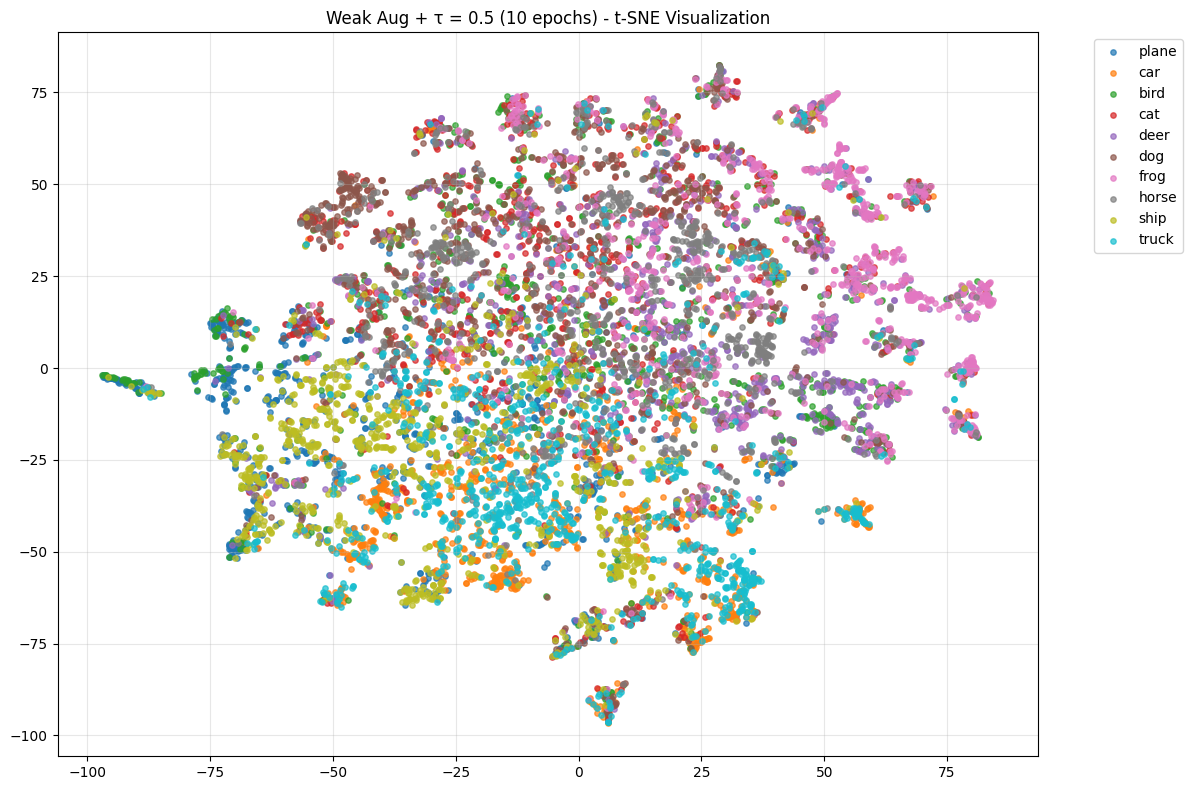

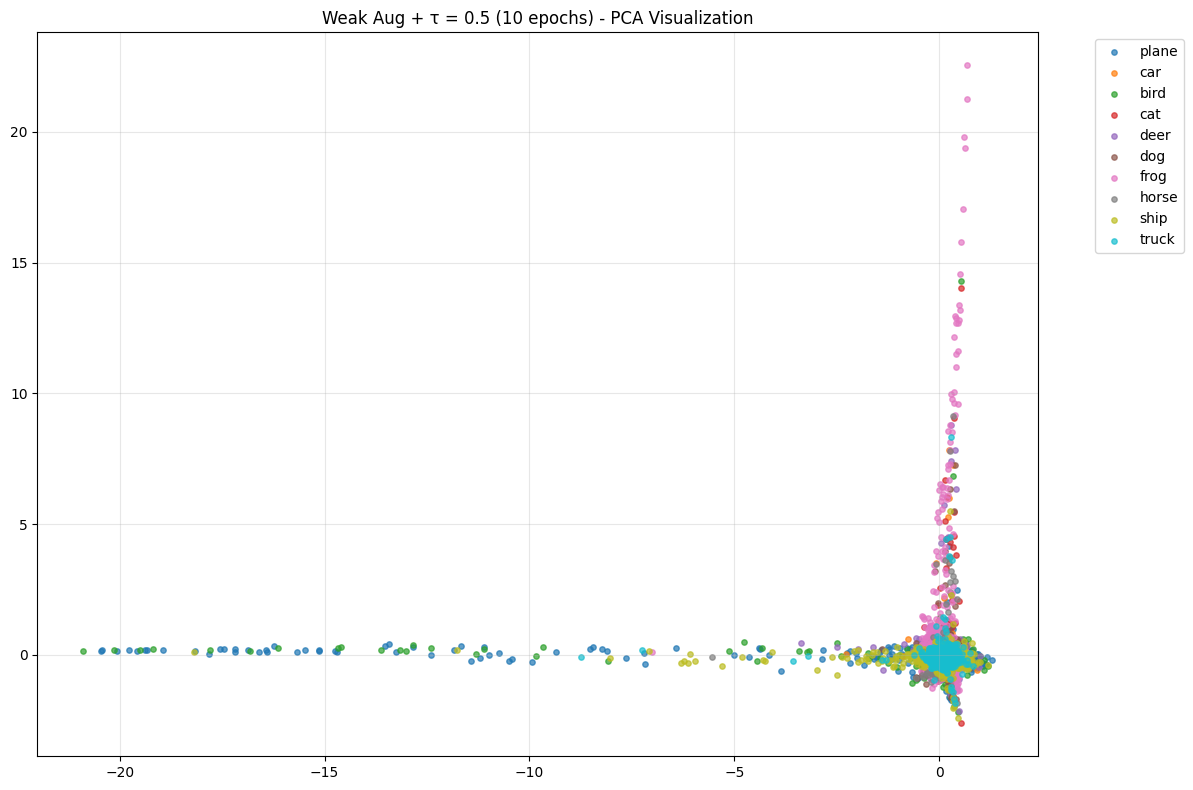


Weak Aug + τ = 0.1 (10 epochs)


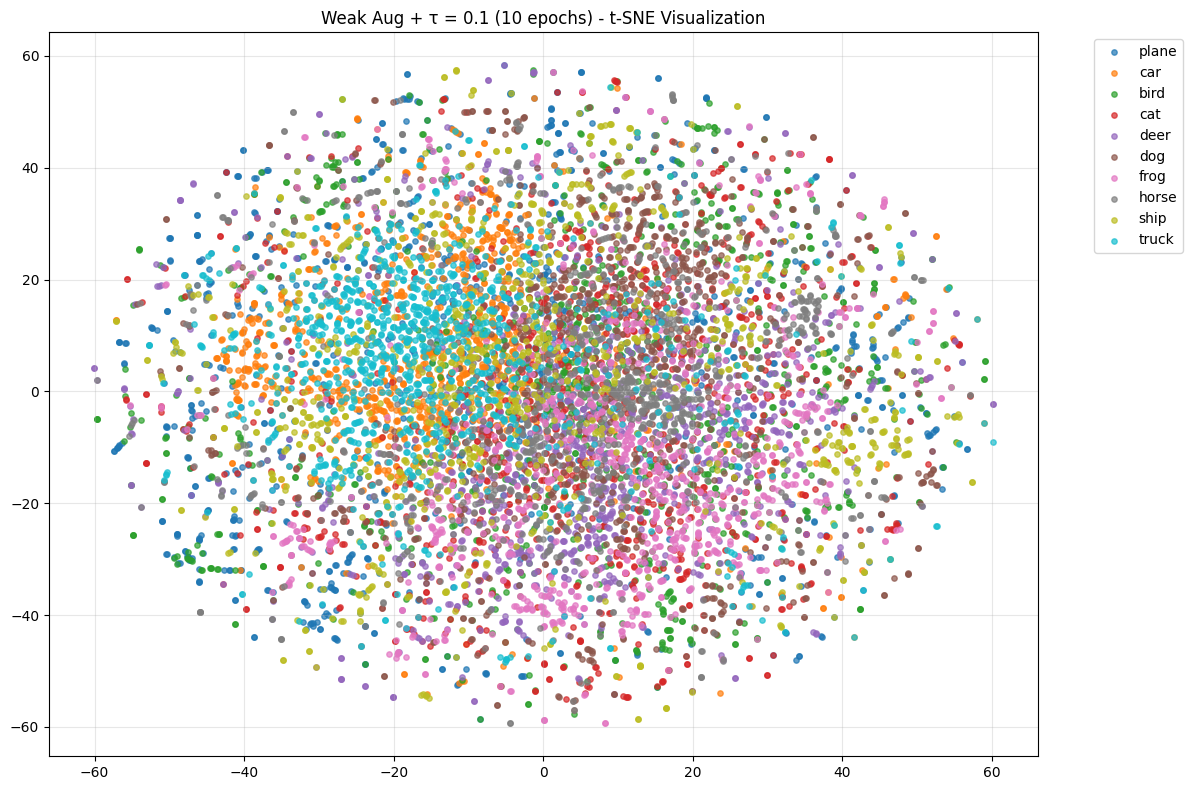

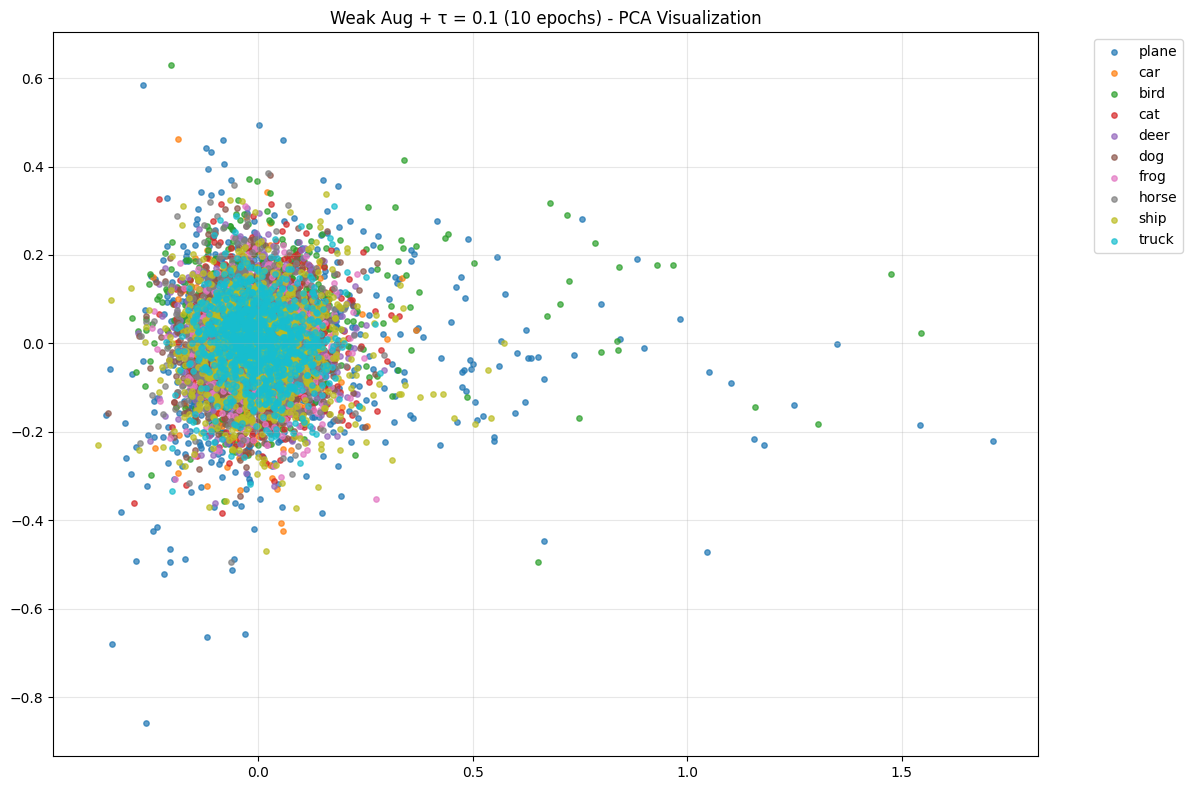

In [16]:
# PCA and t-SNE for both models
print(" Generating PCA and t-SNE visualizations...")

def plot_embedding(emb, labels, title, method='t-SNE'):
    if method == 't-SNE':
        reduced = TSNE(n_components=2, random_state=42, n_jobs=-1).fit_transform(emb)
    else:
        reduced = PCA(n_components=2).fit_transform(emb)

    plt.figure(figsize=(12, 8))
    for i in range(10):
        mask = labels == i
        plt.scatter(reduced[mask, 0], reduced[mask, 1],
                    label=classes[i], alpha=0.7, s=15)
    plt.title(f"{title} - {method} Visualization")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

for name, (emb, lbls) in model_dict.items():
    print(f"\n{name}")
    plot_embedding(emb, lbls, name, 't-SNE')
    plot_embedding(emb, lbls, name, 'PCA')


 Cosine Similarity Analysis (Positive vs Negative)...


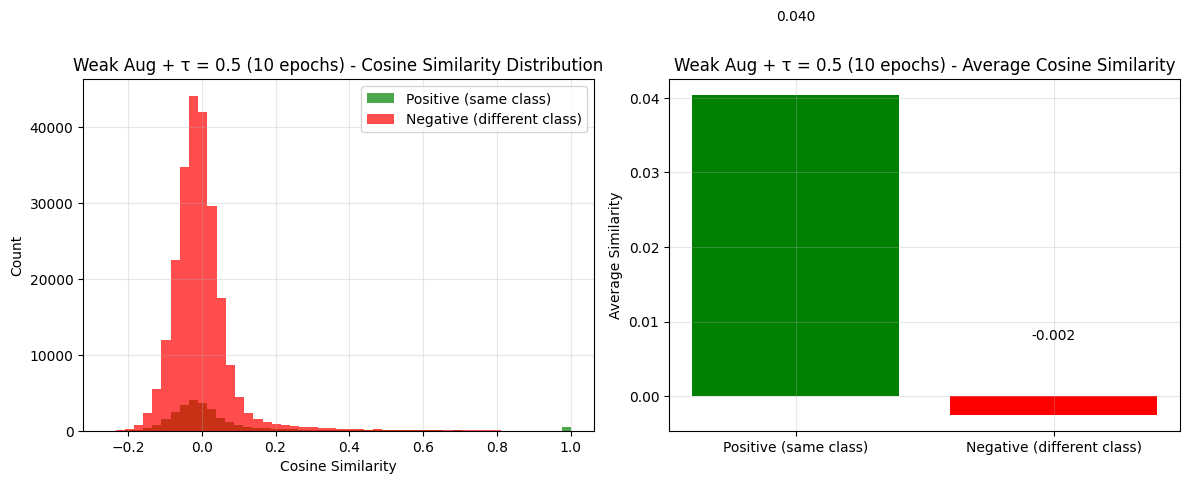

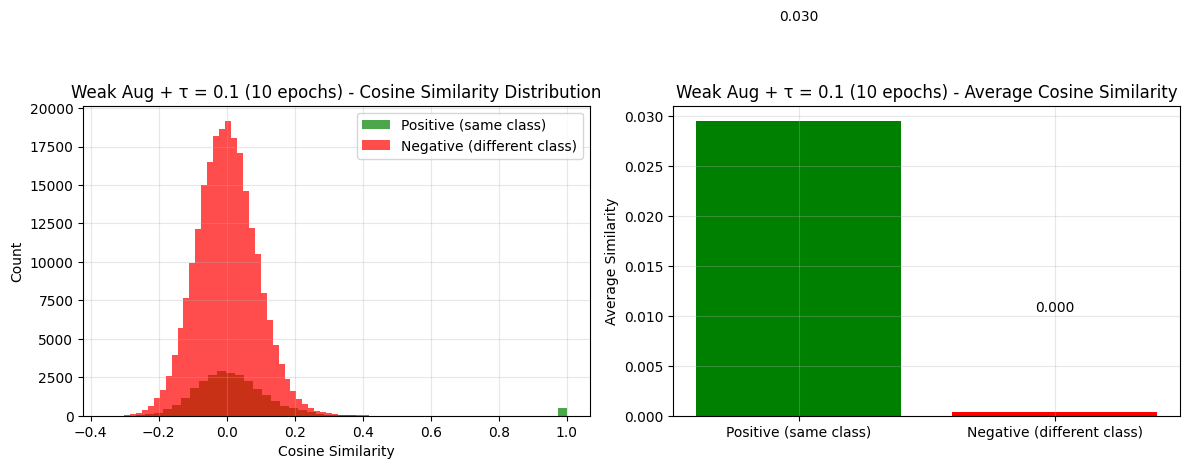

In [17]:
# Cosine Similarity Distribution + Average
print("\n Cosine Similarity Analysis (Positive vs Negative)...")

for name, (emb, lbls) in model_dict.items():
    idx = np.random.choice(len(emb), 512, replace=False)
    batch_emb = torch.tensor(emb[idx], dtype=torch.float32, device='cpu')
    batch_emb = F.normalize(batch_emb, dim=1)
    sim_matrix = torch.mm(batch_emb, batch_emb.T)

    pos_sims, neg_sims = [], []
    for i in range(len(batch_emb)):
        same_class = lbls[idx] == lbls[idx][i]
        sim_row = sim_matrix[i]
        pos_sims.extend(sim_row[same_class].tolist())
        neg_sims.extend(sim_row[~same_class].tolist())

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.hist(pos_sims, bins=50, alpha=0.7, label='Positive (same class)', color='green')
    plt.hist(neg_sims, bins=50, alpha=0.7, label='Negative (different class)', color='red')
    plt.title(f"{name} - Cosine Similarity Distribution")
    plt.xlabel("Cosine Similarity")
    plt.ylabel("Count")
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    avg_pos = np.mean(pos_sims)
    avg_neg = np.mean(neg_sims)
    plt.bar(['Positive (same class)', 'Negative (different class)'],
            [avg_pos, avg_neg], color=['green', 'red'])
    plt.title(f"{name} - Average Cosine Similarity")
    plt.ylabel("Average Similarity")
    for i, v in enumerate([avg_pos, avg_neg]):
        plt.text(i, v + 0.01, f"{v:.3f}", ha='center')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()